In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Chart styling — consistent across all your projects
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#2D6A4F', '#52B788', '#B7E4C7']  # your portfolio color theme

In [2]:
df = pd.read_csv('2019-Oct.csv')


print(df.shape)
print(df.dtypes)
df.head()

(42448764, 9)
event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             object
price            float64
user_id            int64
user_session      object
dtype: object


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## Dataset Overview
The dataset contains user behavior events from a multi-category e-commerce store.
Each row represents a single event: a product view, cart add, or purchase.
Our goal is to isolate purchase events and build RFM features per user.

In [3]:
# Keep only purchase events
df_orders = df[df['event_type'] == 'purchase']

print(f"Total events: {len(df):,}")
print(f"Purchase events: {len(df_orders):,}")
print(f"Unique users who purchased: {df_orders['user_id'].nunique():,}")
print(f"Date range: {df_orders['event_time'].min()} → {df_orders['event_time'].max()}")

Total events: 42,448,764
Purchase events: 742,849
Unique users who purchased: 347,118
Date range: 2019-10-01 00:02:14 UTC → 2019-10-31 23:59:16 UTC


In [4]:
# Parse dates
df_orders['event_time'] = pd.to_datetime(df_orders['event_time'], utc=True)

df_orders['event_date'] = df_orders['event_time'].dt.date
reference_date = df_orders['event_date'].max() + pd.Timedelta(days=1)

C:\Users\soumy\AppData\Local\Temp\ipykernel_30032\1688240126.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_orders['event_time'] = pd.to_datetime(df_orders['event_time'], utc=True)


In [9]:
# RFM(Recency, Frequency, Monetary value) model

# rfm = df_orders.groupby('user_id').agg(
#     recency   = ('event_time', max),
#     frequency = ('user_id',   'count'),
#     monetary  = ('price',      'sum')
# ).reset_index()


rfm = df_orders.groupby('user_id').agg(
    recency=('event_date', lambda x: (reference_date - x.max()).days),
    frequency=('user_id', 'count'),
    monetary=('price', 'sum')
).reset_index()

rfm = rfm[rfm['monetary'] > 0]   # remove zero-spend edge cases
print(rfm.shape)
rfm.describe()

C:\Users\soumy\AppData\Local\Temp\ipykernel_30032\3515571384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_orders['event_date'] = df_orders['event_time'].dt.date


(347118, 4)


,user_id,recency,frequency,monetary
count,3.471180e+05,347118.000000,347118.000000,347118.000000
mean,5.359970e+08,14.599566,2.140047,662.476455
std,1.849860e+07,8.670692,3.639296,2074.370475
min,2.646498e+08,1.000000,1.000000,0.880000
25%,5.171042e+08,7.000000,1.000000,107.590000
50%,5.351679e+08,14.000000,1.000000,246.520000
75%,5.548038e+08,21.000000,2.000000,595.015000
max,5.662783e+08,31.000000,322.000000,265569.520000


## RFM Distributions
Before clustering we check for skew. RFM data is almost always right-skewed —
a small number of high-value customers pull the mean up significantly.

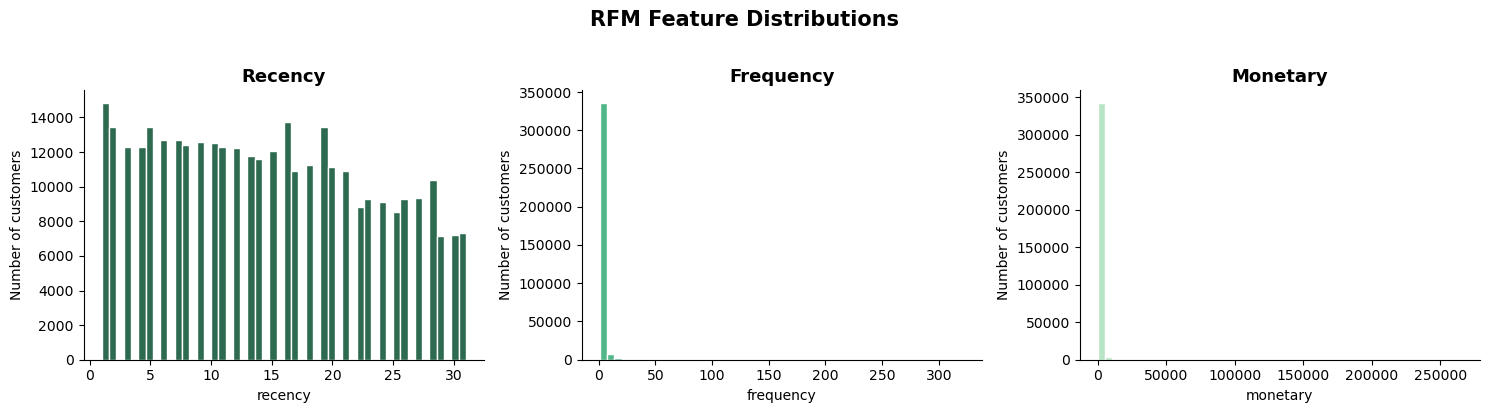

In [10]:
# RFM distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['recency', 'frequency', 'monetary'], PALETTE):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white')
    ax.set_title(col.capitalize(), fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of customers')

plt.suptitle('RFM Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Log transform to handle skew

rfm_log = rfm.copy()

rfm_log['recency']   = np.log1p(rfm['recency'])
rfm_log['frequency'] = np.log1p(rfm['frequency'])
rfm_log['monetary']  = np.log1p(rfm['monetary'])

print("Skew before log transform:")
print(rfm[['recency','frequency','monetary']].skew().round(2))
print("\nSkew after log transform:")
print(rfm_log[['frequency','monetary']].skew().round(2))

Skew before log transform:
recency       0.17
frequency    16.76
monetary     34.08
dtype: float64

Skew after log transform:
frequency    2.31
monetary     0.12
dtype: float64


## Customer Segmentation via K-Means Clustering
With RFM features engineered and skew reduced, we now cluster customers into
distinct segments. We first scale the features, then use the elbow method and
silhouette score to choose the optimal number of clusters.

In [14]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['recency', 'frequency', 'monetary']])

print("Mean after scaling:", rfm_scaled.mean(axis=0).round(3))
print("Std after scaling: ", rfm_scaled.std(axis=0).round(3))

Mean after scaling: [0. 0. 0.]
Std after scaling:  [1. 1. 1.]


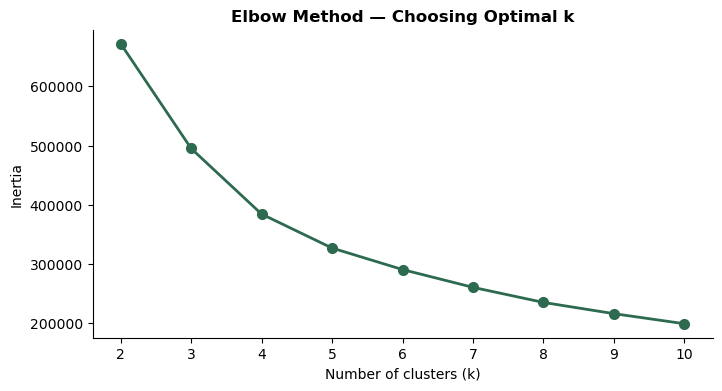

In [15]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color=PALETTE[0], linewidth=2, markersize=7)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing Optimal k', fontweight='bold')
plt.xticks(k_range)
plt.savefig('../outputs/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Silhouette score is run to validate the the choice of number of cluster. It is not an absolute necessity to run.
# Are the resulting clusters actually well separated from each other?-Silhouette score answers it. 
# But it may take a lot of time to run for a large dataset
# So as a workaround I ma running the score for a sample of 15000

sample_size = min(15000, len(rfm_scaled))

sample_idx = np.random.RandomState(42).choice(
    len(rfm_scaled),
    size=sample_size,
    replace=False
)

rfm_sample = rfm_scaled[sample_idx]

sil_scores = []

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(rfm_sample)

    sil_scores.append(
        silhouette_score(rfm_sample, labels)
    )

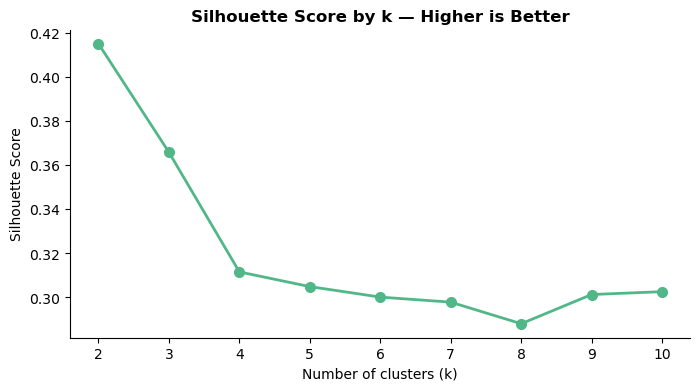

Best k by silhouette score: 2


In [23]:
plt.figure(figsize=(8, 4))
plt.plot(
    k_range,
    sil_scores,
    marker='o',
    color=PALETTE[1],
    linewidth=2,
    markersize=7
)

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k — Higher is Better', fontweight='bold')
plt.xticks(k_range)
plt.show()

best_k = k_range[sil_scores.index(max(sil_scores))]

print(f"Best k by silhouette score: {best_k}")

## Choosing Final k

Silhouette score (sampled, n=15,000) recommended k=2, which is statistically
clean but too coarse for actionable marketing segments. The elbow curve on the
full dataset shows diminishing inertia returns after k=4, suggesting 4 clusters
strike the right balance between statistical separation and business utility.

Final choice: **k=4**

This is a deliberate analytical decision — in a real business context, this would
be validated with the marketing team to ensure segments are large enough to act on.

In [37]:
# Use best_k from silhouette — override here if elbow suggests differently
FINAL_K = 4   #best_k

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

print(f"Cluster sizes:\n{rfm['cluster'].value_counts().sort_index()}")

Cluster sizes:
0    119736
1     37868
2     71516
3    117998
Name: cluster, dtype: int64


## Segment Profiling
We now look at the mean RFM values per cluster to understand what each group
represents. Recency is interpreted inversely — lower recency = more recent purchase.

In [38]:
profile = rfm.groupby('cluster').agg(
    recency_mean   = ('recency',   'mean'),
    frequency_mean = ('frequency', 'mean'),
    monetary_mean  = ('monetary',  'mean'),
    customer_count = ('user_id',   'count')
).round(2)

profile['pct_of_base'] = (profile['customer_count'] / len(rfm) * 100).round(1)
print(profile)

         recency_mean  frequency_mean  monetary_mean  customer_count  \
cluster                                                                
0               18.50            1.68         638.84          119736   
1                8.60            8.06        3121.60           37868   
2                4.10            1.47         339.88           71516   
3               18.93            1.12          92.79          117998   

         pct_of_base  
cluster               
0               34.5  
1               10.9  
2               20.6  
3               34.0  


In [41]:
# Adjust these labels based on what your profile table shows
segment_map = {
    0: 'At-Risk Loyalists',  # decent spend but frequency dropping, going cold
    1: 'Champions',          # recent, highly frequent, highest monetary value
    2: 'Promising Newcomers',# very recent but low spend — early in lifecycle
    3: 'Dormant'             # oldest recency, lowest frequency and spend
}

rfm['segment'] = rfm['cluster'].map(segment_map)
print(rfm['segment'].value_counts())

At-Risk Loyalists      119736
Dormant                117998
Promising Newcomers     71516
Champions               37868
Name: segment, dtype: int64


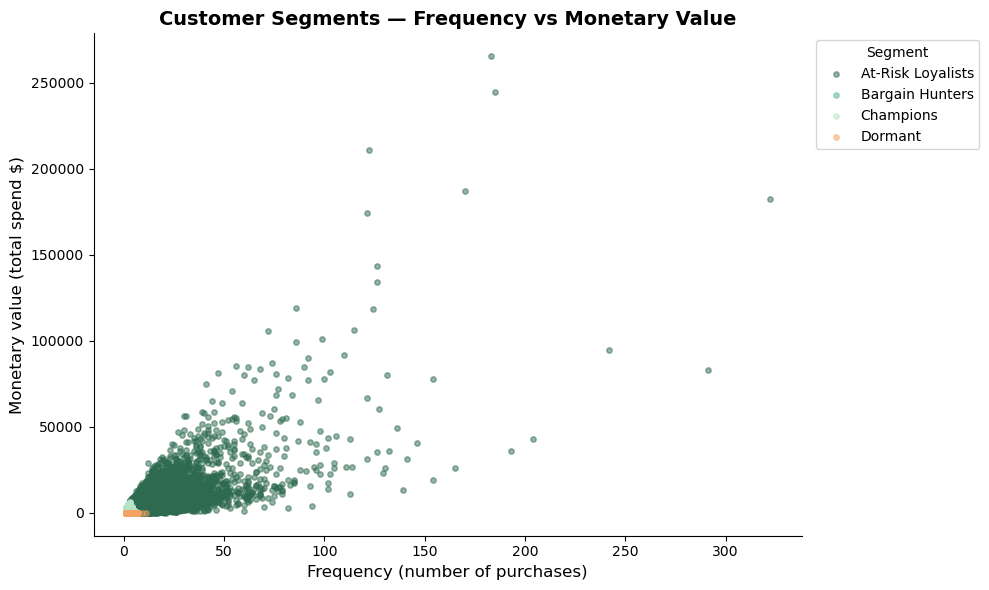

In [40]:
colors = ['#2D6A4F', '#52B788', '#B7E4C7', '#F4A261']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (seg, group) in enumerate(rfm.groupby('segment')):
    ax.scatter(group['frequency'], group['monetary'],
               label=seg, alpha=0.5, s=15, color=colors[i])

ax.set_xlabel('Frequency (number of purchases)', fontsize=12)
ax.set_ylabel('Monetary value (total spend $)', fontsize=12)
ax.set_title('Customer Segments — Frequency vs Monetary Value', fontsize=14, fontweight='bold')
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/segment_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Recommendations

| Segment | Size | Strategy |
|---|---|---|
| **Champions** (10.9%) | 37,868 | Enroll in VIP loyalty program; offer early access to new products; use as referral advocates |
| **Promising Newcomers** (20.6%) | 71,516 | Send a second-purchase incentive within 7 days — this window is critical to convert one-time buyers into repeat customers |
| **At-Risk Loyalists** (34.5%) | 119,736 | Trigger a win-back campaign now; personalize based on past category purchases; time-limited offer |
| **Dormant** (34.0%) | 117,998 | One re-engagement email with a strong discount; if no open in 14 days, move to suppression list |

> **Key insight:** Champions represent only 10.9% of customers but likely drive
> a disproportionate share of revenue (avg spend $3,122 vs $93 for Dormant).
> Protecting this segment should be the top retention priority.
>
> **Quick win:** The Promising Newcomers segment (71,516 customers, avg $340 spend)
> are highly recent — a well-timed second-purchase nudge could significantly
> increase their lifetime value before they go cold.